In [6]:
from collections import Counter
import json
from pathlib import Path
import random
import re
from typing import List


from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import textwrap


from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings


from transformers import AutoTokenizer

from typing import Literal
from pydantic import BaseModel, Field

pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
with open('../data/articles.json', 'r', encoding='utf-8') as f:
    articles = json.load(f)
    
with open('../data/ground_truth.json', 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

with open('../data/questions.json', 'r', encoding='utf-8') as f:
    questions = json.load(f)

In [32]:
build_ollama_payload("Тест", max_tokens=50)

{'model': 'mistral:7b-instruct-v0.3-q4_K_M',
 'prompt': 'Тест',
 'stream': False,
 'options': {'temperature': 0.3, 'num_ctx': 128}}

1. Проверка на дубликатыы

In [5]:
print(f"Количество дубликатов в текстах: ", len(set([article['text'] for article in articles])) - len([article['text'] for article in articles]))
print(f"Количество дубликатов в топиках: ", len(set([article['title'] for article in articles])) - len([article['title'] for article in articles]))

Количество дубликатов в текстах:  0
Количество дубликатов в топиках:  0


2. Посмотрим на среднее и оценим разброс

In [6]:
length_text, length_topic = [], []
for article in articles:
    length_text.append(len(article['text']))
    length_topic.append(len(article['title']))

print(f'Средняя длина заголовка: {np.mean(length_topic):.1f}')
print(f"Средняя длина текста: {np.mean(length_text):.1f}")
pd.DataFrame({'Длина текстов': length_text,
              'Длина топика': length_topic,
              'Отклонение от средней длины текста': (length_text - np.mean(length_text)) * 100 / np.mean(length_text), 
              'Отклонение от среднего длины топика': (length_topic - np.mean(length_topic)) * 100 / np.mean(length_topic)
              })

Средняя длина заголовка: 47.6
Средняя длина текста: 784.8


,Длина текстов,Длина топика,Отклонение от средней длины текста,Отклонение от среднего длины топика
0,866,55,10.35,15.55
1,823,49,4.87,2.94
2,730,41,-6.98,-13.87
3,805,52,2.57,9.24
4,772,43,-1.63,-9.66
5,728,50,-7.24,5.04
6,785,55,0.03,15.55
7,767,55,-2.27,15.55
8,754,32,-3.92,-32.77
9,818,44,4.23,-7.56


3. Посмотрим на случайные документы. Проверим, есть ли артефакты или мусор в статье

In [7]:
for article in random.sample(articles, 5):
    print(article['title'])
    print(article['text'])
    print('=' * 80)

Руководство по управлению доступами и ролями
Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14 календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня admin требуют двойного согласования: руководителя функции и службы информационной безопасности. Ежеквартально владельцы систем обязаны проводить access review и подтверждать актуальность прав пользователей; неподтвержденные права блокируются через 5 рабочих дней после завершения кампании review. Для подрядчиков максимальный срок доступа ограничен датой контракта, но не более 90 дней без повторного согласования. Передача учетных данных третьим лицам запрещена и квалифицируется как грубое нарушение политики безопасности.
Положение о резервном копировании и восстановлении
Для всех продакшн-сервисов применяются политики резервного копирования по схеме 3-2-1

- Данные достаточно качественные, в них нет мусора, артефактов
- Топик по смыслу совпадает с текстом

4. Проверим распределение токенов

Средняя коли токена: 258.0
Максимальное количество токенов: 294


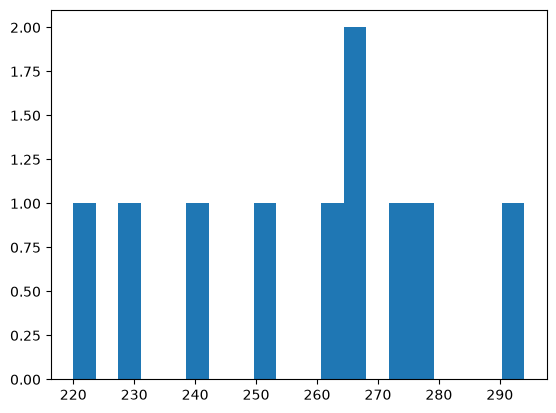

In [8]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-4b')

length_token = (
    [
        len(tokenizer.encode(article['text'], add_special_token=False)) 
        for article in articles
    ]
)

print(f'Средняя коли токена: {np.mean(length_token):.1f}')
print(f'Максимальное количество токенов: {max(length_token)}')
plt.hist(length_token, bins=20);

Объединим вопросы и ответы в один список

In [27]:
index = {truth["id"]: truth for truth in ground_truth}

q_and_a = [
    {**question, **index[question["id"]]}
    for question in questions
]

In [28]:
q_and_a

[{'id': 'q1',
  'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.'},
 {'id': 'q2',
  'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.'},
 {'id': 'q3',
  'question': 'Какой лимит на проживание по Европе указан в документе о командировках?',
  'answer': 'Лимит на проживание по Европе — 160 евро за ночь.'},
 {'id': 'q4',
  'question': 'Какие суточные предусмотрены для сотрудников уровня Specialist и Senior?',
  'answer': 'Для Specialist и Senior суточные составляют 2500 рублей в сутки.'},
 {'id': 'q5',
  'question': 'В каком случае разрешается покупать билеты не в эконом-классе?',
  'answer': 'Неэконом-класс разрешен при перелете дольше 8 часов и наличии медицинского заключения.'},
 {'id': 'q6',
  'question': 'В какой срок нужно загрузить закрывающие д

In [1]:
import os
os.chdir("..")

In [2]:
from src.evaluation import extract_answers, compute_bleu, compute_rouge
from src.data_loader import load_json
from src.retrieval import retrieve_documents, build_context
from src.generation import answer_without_rag, answer_with_rag
from src.judge import judge_answer, explain_judgement
from src.indexing import create_documents, build_embeddings


In [3]:
path = "data/llm_rag_answers_judge.json"
article_path = "data/articles.json"
question_path = "data/questions.json"

result = load_json(path)
articles = load_json(article_path)
questions = load_json(question_path)

In [7]:
documents = create_documents(articles)
article_embeddings = build_embeddings(documents)
query = random.sample(questions, 1)[0]['question']

In [8]:
answer_without_rag(query)

'Не знаю.'

In [9]:
retrieve_doc = retrieve_documents(
    query,
    documents,
    article_embeddings
)

In [10]:
context = build_context(retrieve_doc)

In [11]:
answer_with_rag(query, context)

'До 1 мая 2026 года.'

In [12]:
query_partial = "Когда SOC зафиксировал всплеск переходов по подозрительным ссылкам в инциденте ИБ-24-117?"

retrieve_doc = retrieve_documents(
    query_partial,
    documents,
    article_embeddings
)

context = build_context(retrieve_doc)

In [13]:
context

'Документ 1\n\n    Заголовок:\n    Отчет по инциденту ИБ-24-117: фишинговая рассылка\n\n    Содержимое:\n    14 марта 2026 года в 09:12 SOC зафиксировал всплеск переходов по подозрительным ссылкам из корпоративной почты. В 09:25 инциденту присвоен уровень High, в 09:40 заблокирован домен-источник, в 10:05 отозваны активные сессии 37 пользователей. Атака была реализована через поддельное письмо от имени HR с темой Обновление графика отпусков. Из 612 получателей 94 открыли письмо, 21 пользователь перешел по ссылке, 6 сотрудников ввели корпоративные учетные данные на поддельной странице. По итогам расследования утечки данных клиентов не выявлено, однако подтверждена компрометация 6 учетных записей сотрудников. В качестве корректирующих мер введены обязательный phishing-simulation тренинг раз в квартал, запрет внешней переадресации писем и принудительное включение FIDO2 для сотрудников финансового блока до 1 мая 2026 года.\n    \n\n===\n\nДокумент 2\n\n    Заголовок:\n    Руководство по он

In [19]:
label_partial = judge_answer(question=query_partial,
             context=context, 
             reference_answer="SOC зафиксировал всплеск в 09:12 14 марта 2026 года.",
             candidate_answer="SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.").label

In [20]:
explain_judgement(question=query_partial,
             context=context, 
             reference_answer="SOC зафиксировал всплеск в 09:12 14 марта 2026 года.",
             candidate_answer="SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.",
             label = label_partial)


JudgeExplanation(reason='Ответ кандидата не указал дату 14 марта 2026 года, что привело к частичной оценке.')

In [21]:
query_incorrect = "Какой лимит на проживание по Европе указан в документе о командировках?"

retrieve_doc = retrieve_documents(
    query_incorrect,
    documents,
    article_embeddings
)

context = build_context(retrieve_doc)

In [22]:
label_incorrect = judge_answer(question=query_incorrect,
             context=context,
             reference_answer="Лимит на проживание по Европе — 160 евро за ночь.",
             candidate_answer="16 евро").label

In [ ]:
explain_judgement(question=query_incorrect,
             context=context,
             reference_answer="Лимит на проживание по Европе — 160 евро за ночь.",
             candidate_answer="16 евро",
             label=label_incorrect)

JudgeExplanation(reason='Кандидат указал 16 евро, а в документе указано 160 евро.')

In [29]:
query_correct = "Что происходит с неподтвержденными правами после квартального access review?"

retrieve_doc = retrieve_documents(
    query_correct,
    documents,
    article_embeddings
)

context = build_context(retrieve_doc)

In [30]:
label_correct =judge_answer(question=query_correct,
             context=context,
             reference_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения review.",
             candidate_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения кампании access review.").label

In [31]:
explain_judgement(question=query_correct,
             context=context,
             reference_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения review.",
             candidate_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения кампании access review.",
             label=label_correct)

JudgeExplanation(reason='Ответ кандидата точно соответствует описанию в документе 1 по сроку блокировки неподтвержденных прав после access review.')

In [19]:
llm_predictions, references = extract_answers(result, "llm_answer")
rag_predictions, references = extract_answers(result, "rag_answer")

llm_bleu = compute_bleu(llm_predictions, references)
rag_bleu = compute_bleu(rag_predictions, references)

llm_rouge = compute_rouge(llm_predictions, references)
rag_rouge = compute_rouge(rag_predictions, references)

In [22]:
metrics = pd.DataFrame({"LLM": [llm_bleu, llm_rouge], "RAG": [rag_bleu, rag_rouge]}, index=['Bleu', 'Rouge-L'])

In [23]:
metrics

,LLM,RAG
Bleu,0.00823,0.308920
Rouge-L,0.02399,0.799941


In [12]:
print(len(llm_predictions))
print(len(rag_predictions))
print(len(references))

print(llm_predictions[0])
print(rag_predictions[0])
print(references[0])
print(bleu_references[0])


50
50
50
Не знаю.
За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.
Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.
['Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.']


In [3]:
with open("../data/llm_rag_answers.json", 'r', encoding='utf-8') as f:
    results = json.load(f)

In [7]:
for item in results:
    judgement = judge_answer(
        question=item["question"],
        context=item["context"],
        reference_answer=item["ground_truth_answer"],
        candidate_answer=item["rag_answer"],
    )

    item["judge_label"] = judgement.label

In [8]:
results

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5834444044068979,
   0.36593242758057937,
   0.3357277663705655],
  'human_feedback': 'correct',
  'error': 'correct',
  'context': 'Документ 1\n\n    Заголовок:\n    Регламент оформления командировок и возмещения расходов\n\n    Содержимое:\n    С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на 

In [10]:
for item in results:
    human_label = item["human_feedback"]
    judge_label_value = item["judge_label"]

    if (
        judge_label_value != human_label
        or judge_label_value in {"partial", "incorrect"}
    ):
        explanation = explain_judgement(
            question=item["question"],
            context=item["context"],
            reference_answer=item["ground_truth_answer"],
            candidate_answer=item["rag_answer"],
            label=judge_label_value,
        )

        item["judge_reason"] = explanation.reason

In [ ]:
output_path = Path('../data/llm_rag_answers.json')

output_path.write_text()

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5834444044068979,
   0.36593242758057937,
   0.3357277663705655],
  'human_feedback': 'correct',
  'error': 'correct',
  'context': 'Документ 1\n\n    Заголовок:\n    Регламент оформления командировок и возмещения расходов\n\n    Содержимое:\n    С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на 

In [39]:
for item in results:
    human_label = item["human_feedback"]
    judge_label_value = item["judge_label"]

    if (
        judge_label_value != human_label
        or judge_label_value in {"partial", "incorrect"}
    ):
        explanation = explain_judgement(
            question=item["question"],
            context=item["context"],
            reference_answer=item["ground_truth_answer"],
            candidate_answer=item["rag_answer"],
            label=judge_label_value,
        )

        item["judge_reason"] = explanation.reason

KeyError: 'judge_label'

In [ ]:
from pathlib import Path



In [13]:
output_path = Path('../data/llm_rag_answers_judge.json')

output_path.write_text(
    json.dumps(results, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

175082

In [ ]:
judge_answer(question="Когда SOC зафиксировал всплеск переходов по подозрительным ссылкам в инциденте ИБ-24-117?",
             reference_answer="SOC зафиксировал всплеск в 09:12 14 марта 2026 года.",
             candidate_answer="SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.")

'{\n  "label": "partial",\n  "reason": "Ответ кандидата не содержит полной даты (только время), что делает информацию неполной. В эталонном ответе указано как'

In [ ]:
judge_answer(question="Какой лимит на проживание по Европе указан в документе о командировках?",
             reference_answer="Лимит на проживание по Европе — 160 евро за ночь.",
             candidate_answer="16 евро")

{'label': 'incorrect',
 'reason': 'Ответ кандидата (16 евро) не соответствует эталонному ответу (160 евро за ночь), что является фактической ошибкой.'}

In [10]:
judge_answer(question="Какие суточные предусмотрены для сотрудников уровня Specialist и Senior?",
             reference_answer="Для Specialist и Senior суточные составляют 2500 рублей в сутки.",
             candidate_answer="Для сотрудников уровня Specialist и Senior предусмотрены суточные в размере 2500 рублей в сутки.")

{'label': 'correct',
 'reason': 'Ответ кандидата содержит все существенные факты эталонного ответа: указывается размер суточных (2500 рублей) и их применение к сотрудникам уровня Specialist и Senior. Формулировка отличается лишь стилистически, но не содержит ошибок или пропусков.'}

In [11]:
llm_errors

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5814867675574096,
   0.36261675868942306,
   0.3334893301611435],
  'human_feedback': 'correct',
  'error': 'correct'},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по России устанавливаются в зависимости от конкретного вида командировки, типа организации и внутренних правил компании или учреждения.\n\nОднако, в соответствии с нормами, регулирующими ком

In [9]:
with open("../data/llm_rag_answers_errors.json", 'r', encoding='utf-8') as f:
    llm_errors = json.load(f)

In [12]:
llm_errors

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5814867675574096,
   0.36261675868942306,
   0.3334893301611435],
  'human_feedback': 'correct',
  'error': 'correct'},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по России устанавливаются в зависимости от конкретного вида командировки, типа организации и внутренних правил компании или учреждения.\n\nОднако, в соответствии с нормами, регулирующими ком

In [24]:
for i in range(len(llm_errors)):
    try:
        result = judge_answer(
            llm_errors[i],
            documents
        )
        llm_errors[i].update({"rag_judge": result})
    except json.JSONDecodeError:
        print(f"Ошибка произошла на {i} записи")

{
    "label": "correct",
    "reason": "Ответ кандидата точно соответствует информации из Документа 1, где указано, что заявка оформляется не позднее чем за 5 р"
}
{
    "label": "correct",
    "reason": "Ответ кандидата точно соответствует эталонному ответу, указывая лимит на проживание по России в размере 9000 рублей за夜,"
}
{
    "label": "incorrect",
    "reason": "В документе указан лимит на проживание по Европе — 160 евро за ночь, а в ответе кандидата указано 16 евро, что являетсяф"}
{
    "label": "correct",
    "reason": "Ответ кандидата передает все существенные факты эталонного ответа: указывает на размер суточных (2500 рублей в сутки) ит" }
{
    "label": "correct",
    "reason": "Ответ кандидата содержит все существенные факты из эталонного ответа: указание на длительность перелета более 8 часов ит" }
{
    "label": "correct",
    "reason": "Ответ кандидата полностью соответствует эталонному ответу по содержанию: указывает срок загрузки закрывающих документов—" }
{
    "la

ResponseError: model runner has unexpectedly stopped, this may be due to resource limitations or an internal error, check ollama server logs for details (status code: 500)

In [ ]:
judge_answer = 

In [27]:
llm_errors

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5814867675574096,
   0.36261675868942306,
   0.3334893301611435],
  'human_feedback': 'correct',
  'error': 'correct',
  'rag_judge': '{\n    "label": "correct",\n    "reason": "Ответ кандидата точно соответствует информации из Документа 1, где указано, что заявка оформляется не позднее чем за 5 р"\n}'},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по Р

In [13]:
test = [{
    "question": "Сколько пользователей ввели учетные данные на поддельной странице?",
    "ground_truth_answer": "Учетные данные ввели 6 пользователей.",
    "llm_answer": "Не знаю.",
    "rag_answer": "6 сотрудников ввели корпоративные учетные данные на поддельной странице.",
    "retrieved_ids": [
      "2",
      "10",
      "9"
    ],
    "retrieved_scores": [
      0.4541750974586608,
      0.31094078487275006,
      0.27880998927985634
    ],
    "human_feedback": "correct",
    "error": "correct"
  }]

In [15]:
judge_answer(test[0], documents)

'{\n    "label": "correct",\n    "reason": "Ответ кандидата содержит всю существенную информацию из эталонного ответа: уточняет, что именно 6 сотрудников ввели учетные данные на поддельной стрни" }'